In [36]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [37]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from bayesgpt.simulators.benchmarks import SuperDDM

In [38]:
# Initialize model
model = SuperDDM(dt=0.001, max_steps=10000)

In [29]:
# Define parameters
params = {
    "v": 0.5,           # Drift rate
    "a": 1.0,           # Boundary separation
    "z": 0.5,           # Starting point fraction
    "tau": 0.1,         # Non-decision time
    "sigma": 1.0,       # Diffusion noise
    "angle": 0.0,       # Collapse rate
    "s_v": 0.1,         # Drift variability
    "s_z": 0.05,        # Starting point variability
    "s_tau": 0.02       # Non-decision time variability
}

In [30]:
# Simulate 100 trials
result = model.simulate(params, num_trials=100)

In [31]:
print("Response Times:", result["rts"])
print("Choices:", result["choices"])

Response Times: [0.18250114 0.23386765 0.18353684 0.17892774 1.20284382 2.36382678
 0.54731292 0.27606824 0.90251941 2.64997256 1.00399911 0.50393119
 0.54524144 0.36064564 3.68988486 0.42554792 1.10825272 0.19863189
 1.10595164 1.16606601 0.11238545 0.28479237 0.13014075 0.56589444
 0.42440888 0.17228516 2.65235572 0.28050908 0.38938293 0.18518502
 0.42631574 0.14216324 0.12274519 0.26448922 0.45501521 1.14489207
 0.72252997 2.47475621 2.23584688 1.60080268 0.36733665 0.78951404
 0.20301806 0.20843935 0.80800925 0.44374354 2.25923305 0.25805328
 0.58142175 0.25395341 0.51832246 0.53421602 0.18094979 1.325288
 1.48325131 0.24356143 0.23939122 0.18844681 0.23844163 1.06706012
 0.18400516 1.59816462 0.24050992 0.2128856  0.21868167 0.86673218
 0.22093429 0.32707259 1.03497808 0.22268746 0.14241994 0.71593246
 0.29093059 0.37681746 0.24588233 0.21666148 0.77212083 0.14518547
 1.39538226 0.87371537 0.33084161 0.22116404 2.19744309 0.40584687
 0.63445738 2.94154494 2.28140767 0.2170806  0.4

In [32]:
params = {
    "v_components": np.array([0.4, 0.6]),
    "a": 1.0,
    "z": 0.5,
    "tau": 0.1,
    "sigma": 1.0,
    "angle": 0.0,
    "s_v": 0.1,
    "s_z": 0.05,
    "s_tau": 0.02
}

In [33]:
result = model.simulate(params, num_trials=100)

In [34]:
print("Response Times:", result["rts"])
print("Choices:", result["choices"])

Response Times: [0.36268911 0.16405009 0.18891349 0.19163431 0.85470898 0.55564328
 0.29182579 0.15441481 0.18246109 0.43254994 0.9284566  0.19530999
 0.23573371 0.43992976 0.72969376 1.01326697 0.0862141  1.50938207
 0.37393157 0.26627357 0.14275236 0.19183794 0.41784619 0.58815822
 0.45544664 0.68604301 0.82585808 0.13958581 0.85005528 0.26875179
 0.23428611 0.54139321 1.09266252 0.76074146 0.66703519 1.81847342
 0.39723561 0.23067523 2.14771364 0.710343   0.2721976  2.02702588
 2.7333787  0.64346186 0.22895073 0.15276048 0.38291918 1.71818882
 3.11497682 0.1410522  0.61624454 0.94344647 0.14457178 0.25670263
 0.63459969 0.30536773 1.9290428  0.49045486 0.98034194 0.37150733
 0.28736051 1.65375582 0.24247294 0.3894101  1.41439445 0.32828371
 2.23720706 0.99425491 0.29636781 0.18593476 0.26576013 0.2971503
 0.21255422 0.38006923 0.3580243  0.28349118 0.22610384 0.2235244
 1.78417306 0.81877026 0.6189044  0.25726499 0.659943   0.37922914
 1.92540635 0.61928936 1.33797026 0.20734692 0.7

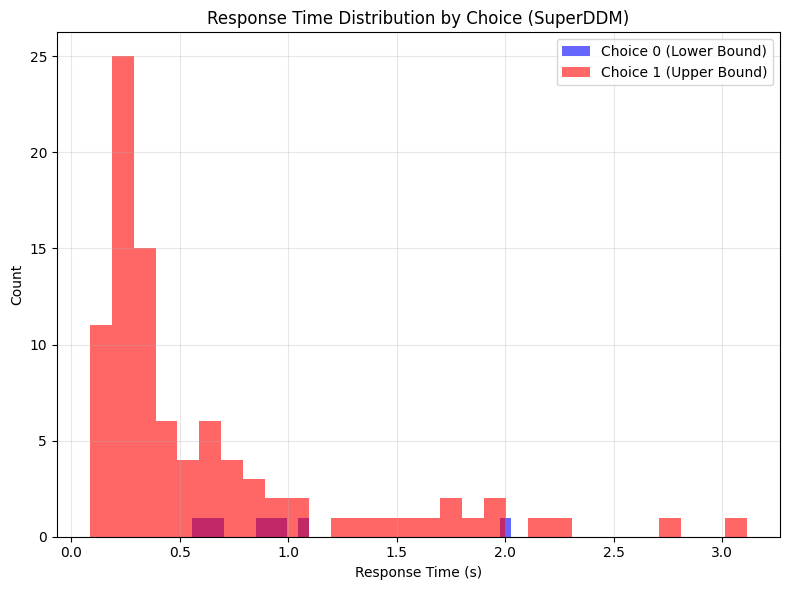

In [35]:
rts = result["rts"]
choices = result["choices"]

# Filter response times by choice
rts_choice_0 = rts[choices == 0]
rts_choice_1 = rts[choices == 1]

# Create histogram
plt.figure(figsize=(8, 6))
plt.hist(rts_choice_0, bins=30, alpha=0.6, color='blue', label='Choice 0 (Lower Bound)')
plt.hist(rts_choice_1, bins=30, alpha=0.6, color='red', label='Choice 1 (Upper Bound)')
plt.title('Response Time Distribution by Choice (SuperDDM)')
plt.xlabel('Response Time (s)')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()